In [24]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import glob
import time
import scipy
import scipy.sparse as sp
from scipy.sparse import csr_matrix, issparse
import anndata as an
import scanpy as sc
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
import matplotlib.patches as mpatches
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from intervaltree import IntervalTree
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
from itertools import chain
import re
import pickle as pkl
from sklearn.decomposition import TruncatedSVD
import pyarrow
from sklearn.preprocessing import MinMaxScaler
import cooler
import pairtools
from matplotlib_venn import venn2

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix as mtrx
import utils as ut
#import plotting as plt2
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

source_path = os.path.abspath("../distribution/tools/")
sys.path.append(source_path)
import sort_comparison as sort_c
import comparison_plots as plot_c
import comparison_extras as extra_c

In [56]:
path_clean = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/singlecell_mESC_1000000_raw.h5ad"

start_time = time.time()  # Record the start time
cdata = sc.read_h5ad(path_clean)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

Time taken to read the file: 243.59 seconds
Memory usage: current 71.01 GB, difference +43.12 GB


In [26]:
path_clean = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_100000_core_current_1.h5ad"

start_time = time.time()  # Record the start time
bdata = sc.read_h5ad(path_clean)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

Time taken to read the file: 0.22 seconds
Memory usage: current 27.89 GB, difference +0.00 GB


In [4]:
path_clean = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_1000000_raw.h5ad"

start_time = time.time()  # Record the start time
adata = sc.read_h5ad(path_clean)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

Time taken to read the file: 17.29 seconds
Memory usage: current 28.92 GB, difference +1.45 GB


In [5]:
mask_1 = cdata.obs_names.str.startswith("chr8:")
cdata_filtered = cdata[mask_1, :].copy()

In [47]:
mask_3 = bdata.obs_names.str.startswith("chr2:")
bdata_filtered = bdata[mask_3, :].copy()

In [41]:
mask_2 = adata.obs_names.str.startswith("chr8:")
adata_filtered = adata[mask_2, :].copy()

In [30]:
def natural_sort_key(bin_label):
    """
    Generate a sort key for genomic bin labels like 'chr8:10', 'chrX:5', etc.
    Splits into chromosome name and bin position for correct numerical ordering.
    """
    match = re.match(r'chr(\w+):(\d+)', bin_label)
    if match:
        chrom, position = match.groups()
        # Handle numeric vs. sex chromosomes (X, Y, M)
        try:
            chrom_num = int(chrom)
        except ValueError:
            chrom_num = {'X': 98, 'Y': 99, 'M': 100}.get(chrom.upper(), 101)
        return (chrom_num, int(position))
    return (float('inf'), 0)  # Fallback for unexpected formats

In [8]:
# Sort the obs index
sorted_index = sorted(cdata_filtered.obs_names, key=natural_sort_key)

# Reindex the AnnData object
cdata_sorted = cdata_filtered[sorted_index, :]

In [59]:
bdata_filtered  = bdata.copy()


# Sort the obs index
sorted_index = sorted(bdata_filtered.obs_names, key=natural_sort_key)

# Reindex the AnnData object
bdata_sorted = bdata_filtered[sorted_index, :]

In [10]:
# Sort the obs index
sorted_index = sorted(adata_filtered.obs_names, key=natural_sort_key)

# Reindex the AnnData object
adata_sorted = adata_filtered[sorted_index, :]

In [62]:
cdata_index = []
bdata_index = []
for i in cdata.obs.index:
    cdata_index.append(i)
for i in bdata.obs.index:
    bdata_index.append(i)

shared_index =[]
for k in cdata_index:
    if k in bdata_index:
        shared_index.append(k)

print(len(cdata_index))
print(len(bdata_index))
print(len(shared_index))



2579
2330
2330


In [63]:
directory_cell = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/single_cell/single_cell/direct"

# ── Single chromosome ─────────────────────────────────────────────────────────
master_cell, files_cell = sort_c.build_master_matrix(
    directory=directory_cell,
    bin_size=1_000_000,
    chrom="8",
    min_mapq=30,
    valid_pair_types=["UU", "RU", "UR"],
    suffix = "o3b82.GRCm39.filtered.pairs"
    
)


Found 1 pairs file(s) in '/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/single_cell/single_cell/direct'
    88 intra-chromosomal contacts on 8

Master matrix shape: (130, 130)
Total contacts (sum/2): 88


In [6]:
directory_pop = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/population/direct/pairs"

master_pop, files_pop = sort_c.build_master_matrix(
    directory=directory_pop,
    bin_size=1_000_000,
    chrom='8',
    min_mapq=30,
    valid_pair_types=["UU", "RU", "UR"],
    suffix=".GRCm39.direct.pairs",
)

Found 4 pairs file(s) in '/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/population/direct/pairs'
    12054 intra-chromosomal contacts on 8
    1329 intra-chromosomal contacts on 8
    7060 intra-chromosomal contacts on 8
    14528 intra-chromosomal contacts on 8

Master matrix shape: (131, 131)
Total contacts (sum/2): 34971


In [73]:
master_cell.shape

(130, 130)

In [65]:
with open('cell_o3b82/cell_o3b82_IM.pkl', 'rb') as file:
    im_cell =  pkl.load(file)

with open('core/core_IM.pkl', 'rb') as file:
    im_core = pkl.load(file)

incidence_sc = im_cell
incidence_core = im_core

In [66]:
union_bins = incidence_sc.index.union(incidence_core.index)

sc_aligned   = incidence_sc.reindex(union_bins, fill_value=0).astype(float)
core_aligned = incidence_core.reindex(union_bins, fill_value=0).astype(float)

H_sc   = sc_aligned.values
H_core = core_aligned.values

cm_sc   = H_sc   @ H_sc.T
cm_core = H_core @ H_core.T
cm_comb = cm_sc  + cm_core

In [70]:
def add_corner_colorbar(fig, ax, im, label, fontsize=7):
    """
    Add a small colorbar anchored to the bottom-right corner of an axes.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
    ax : matplotlib.axes.Axes
        The parent axes the colorbar should sit inside.
    im : mappable
        The image/mappable to attach the colorbar to.
    label : str
        Colorbar label.
    fontsize : int
        Font size for colorbar tick labels and title.

    Returns
    -------
    cbar : matplotlib.colorbar.Colorbar
    """
    # Place a small inset axes in the bottom-right corner of the parent axes
    # [x0, y0, width, height] in axes-fraction coordinates
    cax = ax.inset_axes([0.72, 0.02, 0.25, 0.03])          # wide & short → horizontal bar
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label, fontsize=fontsize, labelpad=2)
    cbar.ax.tick_params(labelsize=fontsize - 1, length=2, pad=1)

    # Make the colorbar frame stand out slightly against the heatmap
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(0.8)

    return cbar

def pad_to_shape_centered(mat, target_shape):
    """Pad a 2-D numpy array with zeros, centering the original content."""
    result = np.zeros(target_shape, dtype=float)
    row_offset = (target_shape[0] - mat.shape[0]) 
    col_offset = (target_shape[1] - mat.shape[1])
    result[
        row_offset : row_offset + mat.shape[0],
        col_offset : col_offset + mat.shape[1]
    ] = mat
    return result

In [71]:
def plot_panel_contact(
    sparse_matrix,
    numpy_matrix,
    spath,
    titles,
    log_transform=True,
    cmap='Reds',
    dpi=200,
    figsize=(7, 7),
    xticklabel_interval=5,
    yticklabel_interval=5,
):
    """
    Plot two contact matrices in a single heatmap split along the diagonal.
    The upper triangle shows the sparse matrix and the lower triangle shows
    the numpy matrix.

    Parameters
    ----------
    sparse_matrix : scipy.sparse.csr_matrix
        Sparse incidence matrix to clique-expand (H @ H^T).
    numpy_matrix : np.ndarray
        Pre-computed contact matrix (plotted as-is).
    spath : str
        Output file path for the saved figure.
    titles : tuple of str
        Labels for (upper-triangle, lower-triangle), used in a legend.
    log_transform : bool
        If True, apply np.log1p to both matrices before plotting.
    cmap : str
        Colormap for both heatmaps.
    dpi : int
        Figure resolution.
    figsize : tuple
        Overall figure size (width, height) in inches.
    xticklabel_interval : int
        Show every Nth x-tick label.
    yticklabel_interval : int
        Show every Nth y-tick label.

    Returns
    -------
    ax : matplotlib.axes.Axes
    matrices : dict
        Raw (untransformed) matrices keyed by panel title.
    """

    # ------------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------------
    # if not issparse(sparse_matrix):
    #     raise TypeError(
    #         f"sparse_matrix must be a scipy sparse matrix, got {type(sparse_matrix)}. "
    #         "Convert with scipy.sparse.csr_matrix(your_array)."
    #     )
    if not isinstance(numpy_matrix, np.ndarray):
        raise TypeError(
            f"numpy_matrix must be a numpy ndarray, got {type(numpy_matrix)}."
        )

    # ------------------------------------------------------------------
    # Build raw matrices
    # Force materialize any AnnData sparse view into a real scipy CSR
    # matrix BEFORE passing to clique_expand
    # ------------------------------------------------------------------
    # if hasattr(sparse_matrix, 'toarray'):
    #     _H = sp.csr_matrix(sparse_matrix)
    # else:
    #     _H = sparse_matrix

    # _expanded = clique_expand(_H)

    # Guarantee we have a dense numpy array regardless of what
    # clique_expand returns
    # if hasattr(_expanded, 'toarray'):
    #     contact_sparse = _expanded.toarray().astype(float)
    # else:
    #     contact_sparse = np.asarray(_expanded, dtype=float)

    contact_sparse = sparse_matrix

    contact_np1 = numpy_matrix.astype(float)

    # ------------------------------------------------------------------
    # Pad to matching shape if matrices differ slightly in size
    # ------------------------------------------------------------------
    if contact_sparse.shape != contact_np1.shape:
        target = (
            max(contact_sparse.shape[0], contact_np1.shape[0]),
            max(contact_sparse.shape[1], contact_np1.shape[1]),
        )
        if contact_sparse.shape != target:
            contact_sparse = pad_to_shape_centered(contact_sparse, target)
        if contact_np1.shape != target:
            contact_np1 = pad_to_shape_centered(contact_np1, target)

    raw_matrices = {
        titles[0]: contact_sparse,
        titles[1]: contact_np1,
    }

    # ------------------------------------------------------------------
    # Optional log transform
    # ------------------------------------------------------------------
    if log_transform:
        m_upper = np.log1p(contact_sparse)
        m_lower = np.log1p(contact_np1)
        cbar_label = 'log(1 + contacts)'
    else:
        m_upper = contact_sparse.copy()
        m_lower = contact_np1.copy()
        cbar_label = 'Contacts'

    # ------------------------------------------------------------------
    # Build the composite matrix
    #   - upper triangle (k >= 1) taken from m_upper
    #   - lower triangle (k <= -1) taken from m_lower
    #   - diagonal (k = 0) averaged for a smooth transition
    # ------------------------------------------------------------------
    n = m_upper.shape[0]
    upper_mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    lower_mask = np.tril(np.ones((n, n), dtype=bool), k=-1)
    diag_mask  = np.eye(n, dtype=bool)

    composite = np.zeros((n, n), dtype=float)
    composite[upper_mask] = m_upper[upper_mask]
    composite[lower_mask] = m_lower[lower_mask]
    composite[diag_mask]  = (np.diag(m_upper) + np.diag(m_lower)) / 2.0
    composite2 = composite[3:, 3:]

    # ------------------------------------------------------------------
    # Global style
    # ------------------------------------------------------------------
    plt.rcParams.update({
        'figure.dpi':     dpi,
        'axes.edgecolor': 'black',
        'axes.linewidth': 2.0,
        'font.family':    'sans-serif',
    })

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # ------------------------------------------------------------------
    # Draw composite heatmap
    # ------------------------------------------------------------------
    sns.heatmap(
        composite2,
        ax=ax,
        cmap=cmap,
        square=True,
        cbar=False,
        linewidths=0,
        xticklabels=False,
        yticklabels=False,
    )

    # ------------------------------------------------------------------
    # Draw diagonal dividing line
    # ------------------------------------------------------------------
    ax.plot([0, n], [0, n], color='black', linewidth=1.2, linestyle='--')

    # ------------------------------------------------------------------
    # Triangle labels as a text legend in the corners
    # ------------------------------------------------------------------
    # ax.text(
    #     0.97, 0.03, titles[1],
    #     transform=ax.transAxes,
    #     ha='left', va='bottom',
    #     fontsize=9, fontweight='bold',
    #     color='black',
    #     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'),
    # )
    # ax.text(
    #     0.03, 0.97, titles[0],
    #     transform=ax.transAxes,
    #     ha='right', va='top',
    #     fontsize=9, fontweight='bold',
    #     color='black',
    #     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'),
    # )

    ax.set_xlabel('', fontsize=9, fontweight='bold')
    ax.set_ylabel('', fontsize=9, fontweight='bold')

    # ------------------------------------------------------------------
    # Single small colorbar anchored below the bottom-right corner
    # ------------------------------------------------------------------
    plt.tight_layout()
    fig.canvas.draw()

    pos = ax.get_position()

    cbar_width  = pos.width  * 0.15
    cbar_height = 0.010
    cbar_left   = pos.x1 - cbar_width
    cbar_bottom = pos.y0 - 0.07

    cax  = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
    im   = ax.collections[0]
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(cbar_label, fontsize=7, labelpad=3)
    cbar.ax.tick_params(labelsize=6, length=2, pad=1)
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(0.8)

    plt.savefig(spath, dpi=dpi, bbox_inches='tight')
    plt.show()
    

    return ax, raw_matrices

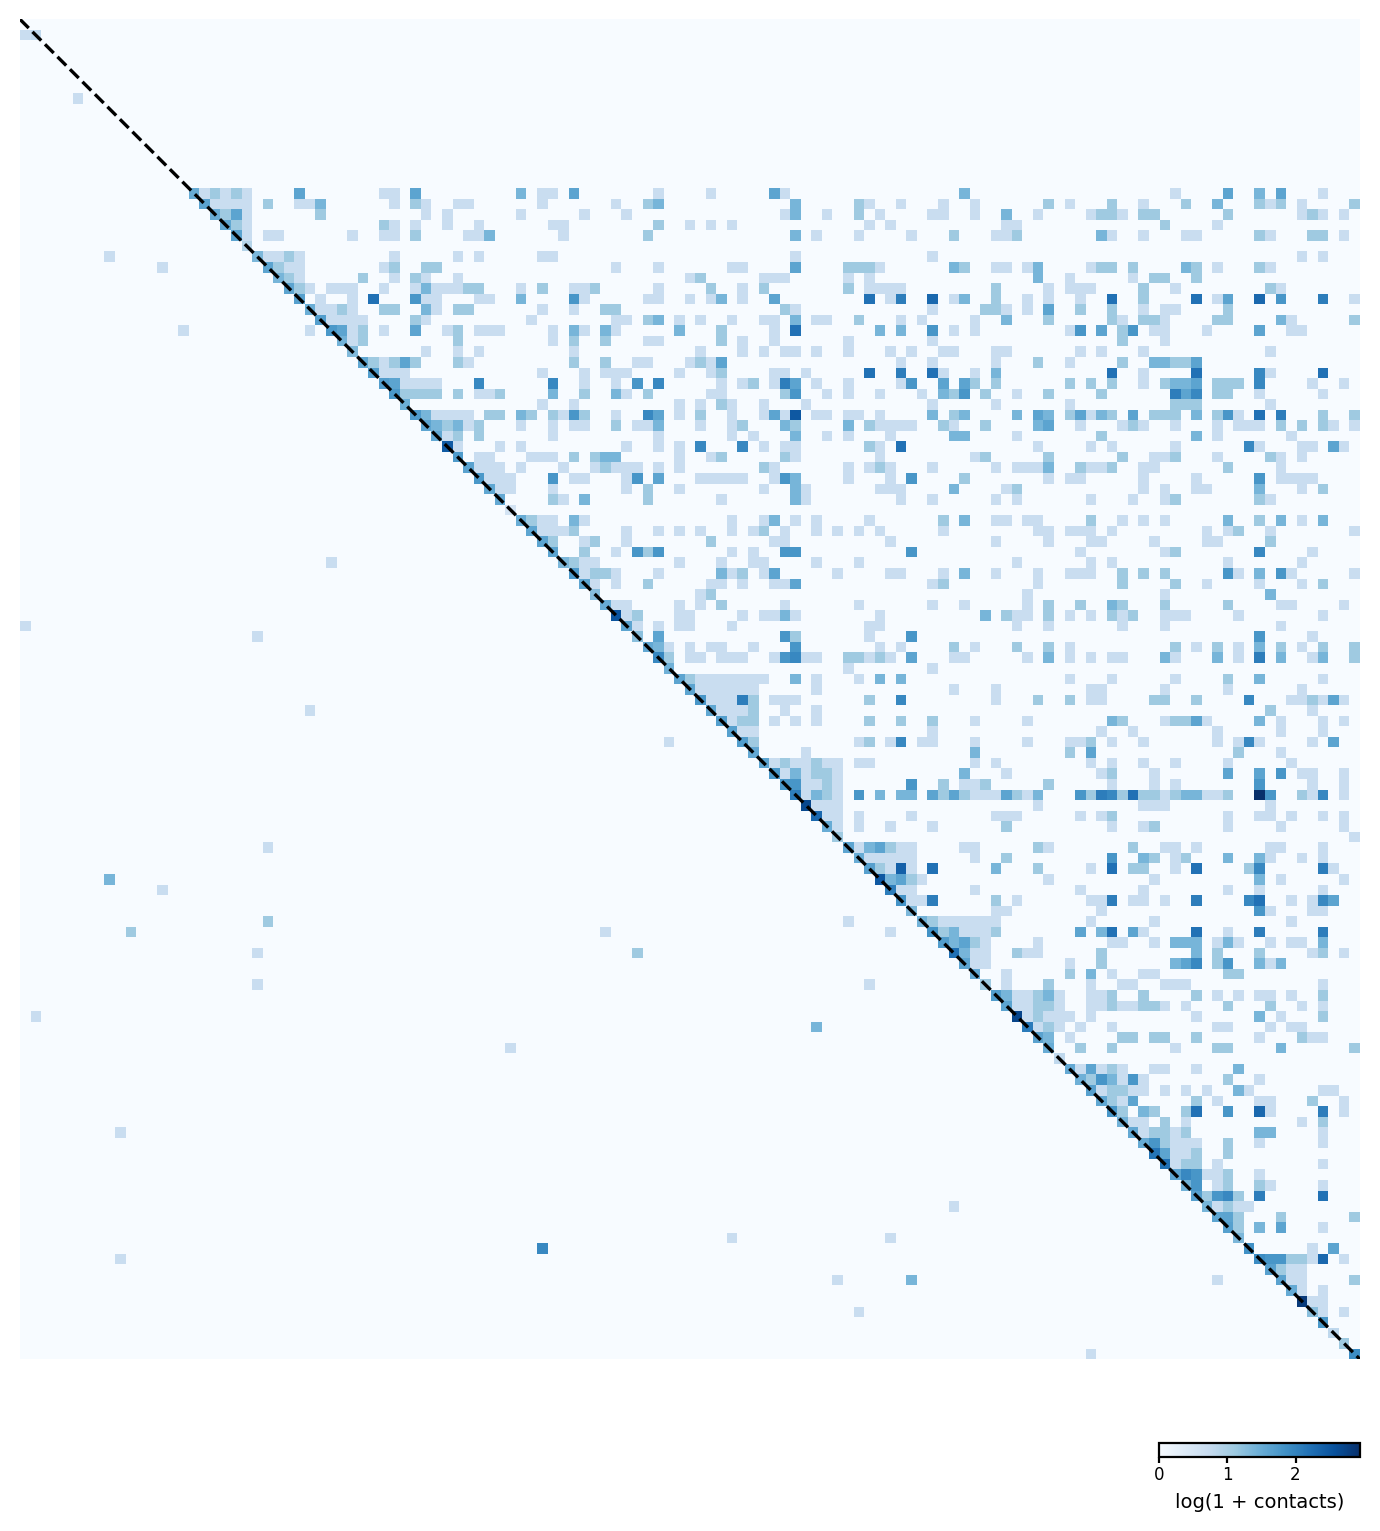

In [72]:
axes, raw_cell = plot_panel_contact(
    sparse_matrix   = cm_comb,
    numpy_matrix    = master_cell,
    spath           = 'core_panel_contact_test.png',
    titles          = ('PoreC - core', 'core - core'),
    log_transform   = True,
    cmap            = 'Blues',
)

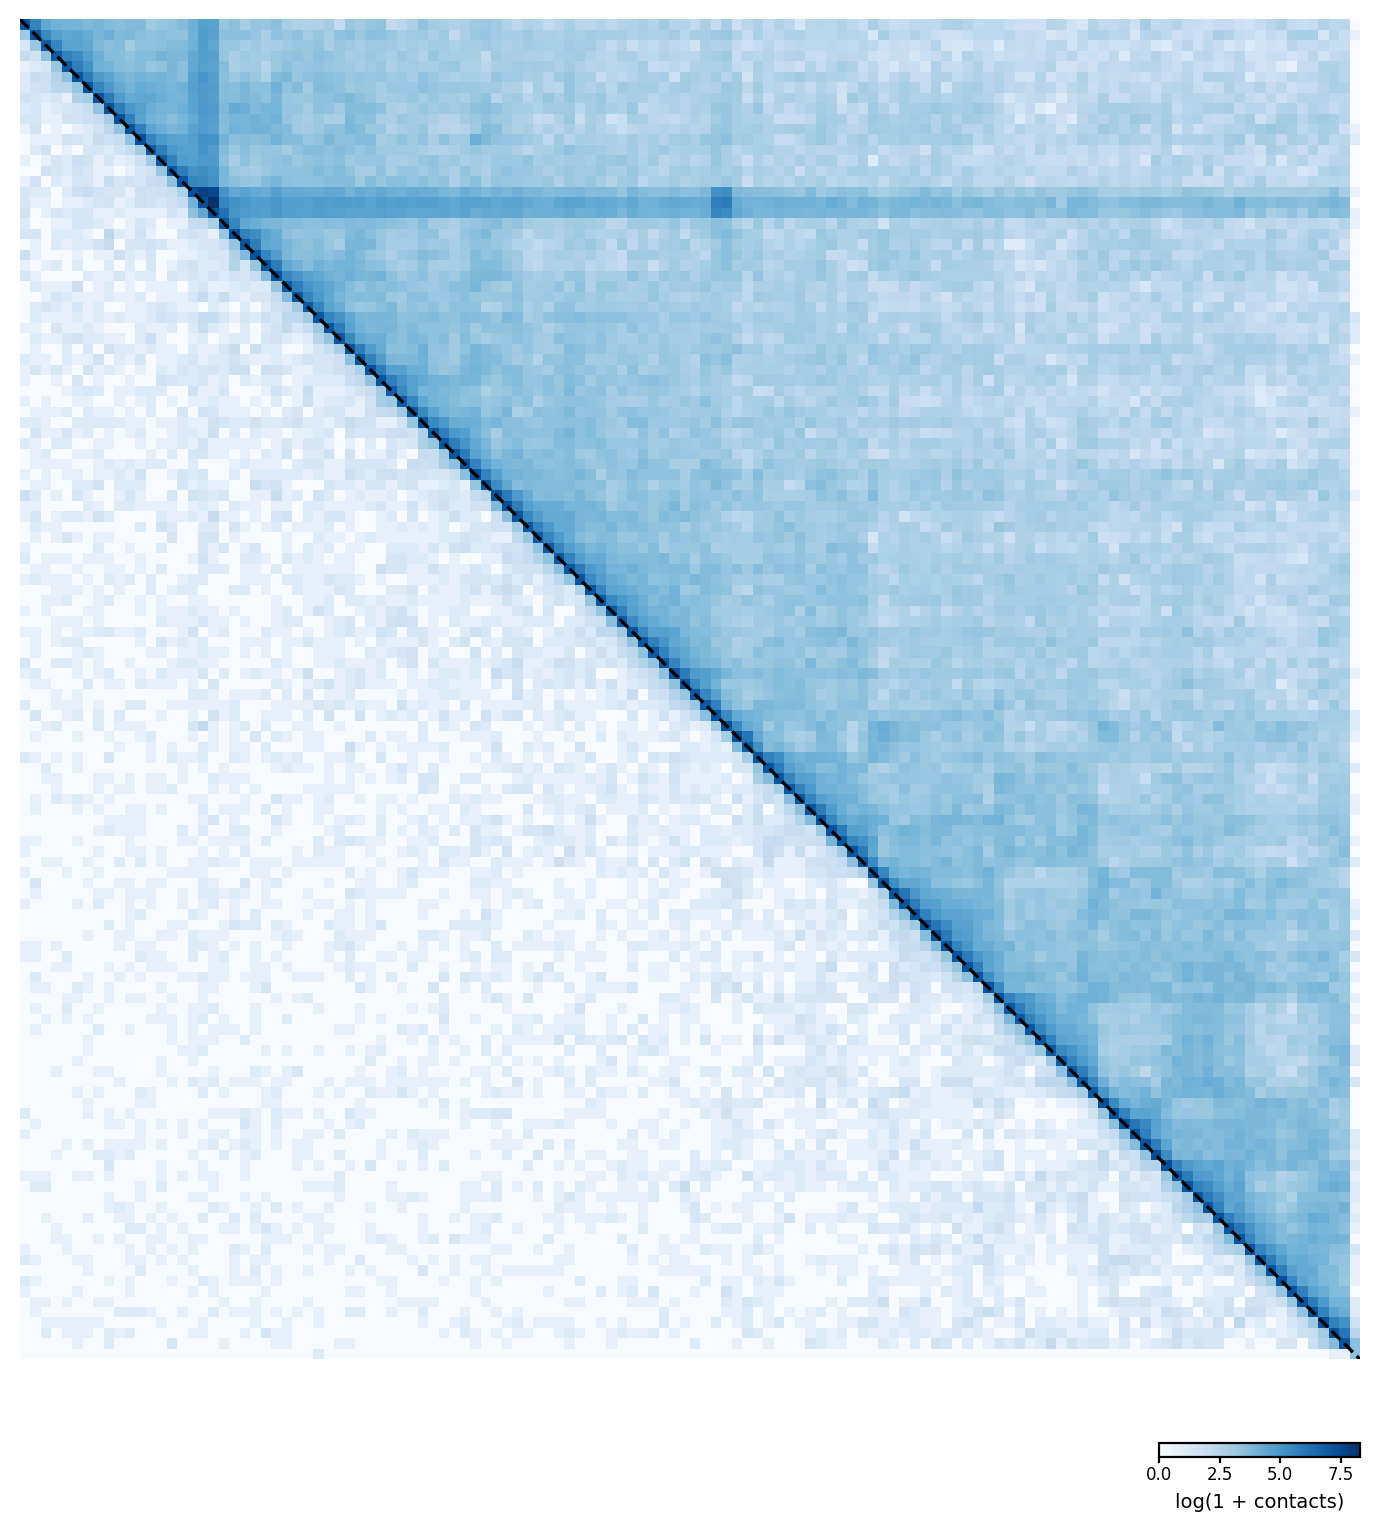

In [14]:
axes, raw_pop = plot_c.plot_panel_contact(
    sparse_matrix   = adata_sorted.X,
    numpy_matrix    = master_pop,
    spath           = 'chr8_panel_contact_pop_test.png',
    titles          = ('scPoreC - Chr8', 'scHiC - Chr8'),
    log_transform   = True,
    cmap            = 'Blues',
)

In [44]:
def jaccard_similarity(A, B):
    A = np.asarray(A).astype(bool)
    B = np.asarray(B).astype(bool)

    intersection = np.logical_and(A, B).sum()
    union = np.logical_or(A, B).sum()

    return intersection / union if union != 0 else 1.0

In [113]:
pore_c = raw_cell['scPoreC - Chr8']
hi_c = raw_cell['scHiC - Chr8']

In [114]:
js = jaccard_similarity(pore_c,hi_c)
print(js)

0.3200144248106744


In [115]:
pore_c = raw_pop['scPoreC - Chr8']
hi_c = raw_pop['scHiC - Chr8']

In [116]:
js = jaccard_similarity(pore_c,hi_c)
print(js)

0.514281746215453


### Cardinality

In [ ]:
# distances, counts, norm, possible = extra_c.compute_interaction_distance_cardinality(
#     raw_pop,
#        # set to None to use full matrix, or limit to a region of interest
# )

# extra_c.plot_interaction_distance_cardinality(
#     distances, counts,
#     chrom="chr8-pop_test",
#     log_scale=True  # recommended — contact counts drop off steeply with distance
# )

### Difference Plots

In [158]:
def compute_contact_set_cardinality(data_dict):
    """
    Compute the set cardinality of non-zero contacts between two matrices.
    Identifies contacts unique to each matrix and shared by both.

    Parameters:
        data_dict:  dict with two matrix entries {label: matrix}

    Returns:
        sets:       dict with keys 'unique_label1', 'unique_label2', 'shared'
                    each containing a set of (i, j) tuples
        counts:     dict with integer counts for each category
        label1:     string, first dict key
        label2:     string, second dict key
    """
    assert len(data_dict) == 2, "Dictionary must contain exactly two matrices."

    labels   = list(data_dict.keys())
    matrices = list(data_dict.values())

    label1, label2 = labels[0], labels[1]

    # Convert sparse to dense
    dense = []
    for mat in matrices:
        dense.append(mat.toarray() if sp.issparse(mat) else np.array(mat, dtype=float))

    assert dense[0].shape == dense[1].shape, (
        f"Shape mismatch: {dense[0].shape} vs {dense[1].shape}"
    )

    # Get non-zero indices as sets of (i, j) tuples
    nonzero1 = set(zip(*np.nonzero(dense[0])))
    nonzero2 = set(zip(*np.nonzero(dense[1])))

    # Compute set operations
    unique1 = nonzero1 - nonzero2
    unique2 = nonzero2 - nonzero1
    shared  = nonzero1 & nonzero2

    sets = {
        f"Unique to {label1}": unique1,
        f"Unique to {label2}": unique2,
        "Shared":              shared
    }

    counts = {key: len(val) for key, val in sets.items()}

    # Print summary
    total = len(nonzero1 | nonzero2)
    print(f"Total non-zero contacts (union): {total:,}")
    for key, val in counts.items():
        print(f"  {key}: {val:,}  ({100 * val / total:.1f}%)")

    return sets, counts, label1, label2

In [300]:
def plot_contact_venn(sets, counts, label1, label2, chrom="chr1"):
    """
    Venn diagram of non-zero contact overlap between two matrices.
    Requires: pip install matplotlib-venn
    """
    unique1 = counts[f"Unique to {label1}"]
    unique2 = counts[f"Unique to {label2}"]
    shared  = counts["Shared"]

    fig, ax = plt.subplots(figsize=(7, 6))

    venn = venn2(
        subsets=(unique1, unique2, shared),
        set_labels=(label1, label2),
        set_colors=("dodgerblue", "crimson"),
        alpha=0.99,
        ax=ax
    )

    # Style the labels
    for text in venn.set_labels:
        if text:
            text.set_visible(False)

    for text in venn.subset_labels:
        if text:
            if text.get_text().strip() == '0':
                text.set_visible(False)
            else:
                text.set_fontsize(9)
                text.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(f"contact_venn_{chrom}.png", dpi=150)
    plt.show()

In [301]:
def plot_contact_barchart(counts, label1, label2, chrom="chr1",
                          xlabel_names=None, bar_spacing=0.6):
    """
    Grouped bar chart showing unique and shared non-zero contact counts.

    Parameters
    ----------
    counts       : dict of category -> count
    label1       : first dataset label
    label2       : second dataset label
    chrom        : chromosome name (used in output filename)
    xlabel_names : list of custom x-axis tick labels
    bar_spacing  : distance between bar centers (default 0.6, lower = closer)
    """
    categories = list(counts.keys())
    values     = list(counts.values())
    colors     = ["dodgerblue", "crimson", "mediumorchid"]
    total      = sum(values)

    # ✅ Custom x positions based on spacing
    x_pos = np.array([i * bar_spacing for i in range(len(categories))])

    fig, ax = plt.subplots(figsize=(7, 5))

    bars = ax.bar(x_pos, values, color=colors, edgecolor="white", width=0.5)

    # Annotate bars with counts and percentages
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.01,
            f"{val:,}\n({100 * val / total:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight='bold'
        )

    # Fit plot window to new positions
    ax.set_xlim(x_pos[0] - bar_spacing * 0.75, x_pos[-1] + bar_spacing * 0.75)
    ax.set_ylim(0, max(values) * 1.2)

    if xlabel_names:
        if len(xlabel_names) != len(categories):
            raise ValueError(
                f"xlabel_names length ({len(xlabel_names)}) must match "
                f"number of categories ({len(categories)})"
            )
        ax.set_xticks(x_pos)
        ax.set_xticklabels(xlabel_names, fontsize=9, fontweight='bold')

    ax.yaxis.set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(True)  # optional: clean up bottom spine too

    plt.tight_layout()
    plt.savefig(f"contact_barchart_{chrom}.png", dpi=150)
    plt.show()

In [49]:
sets, counts, label1, label2 = plot_c.compute_contact_set_cardinality(raw_pop)

# Individual plots
plot_c.plot_contact_venn(sets, counts, label1, label2, chrom="chr8")

NameError: name 'raw_pop' is not defined

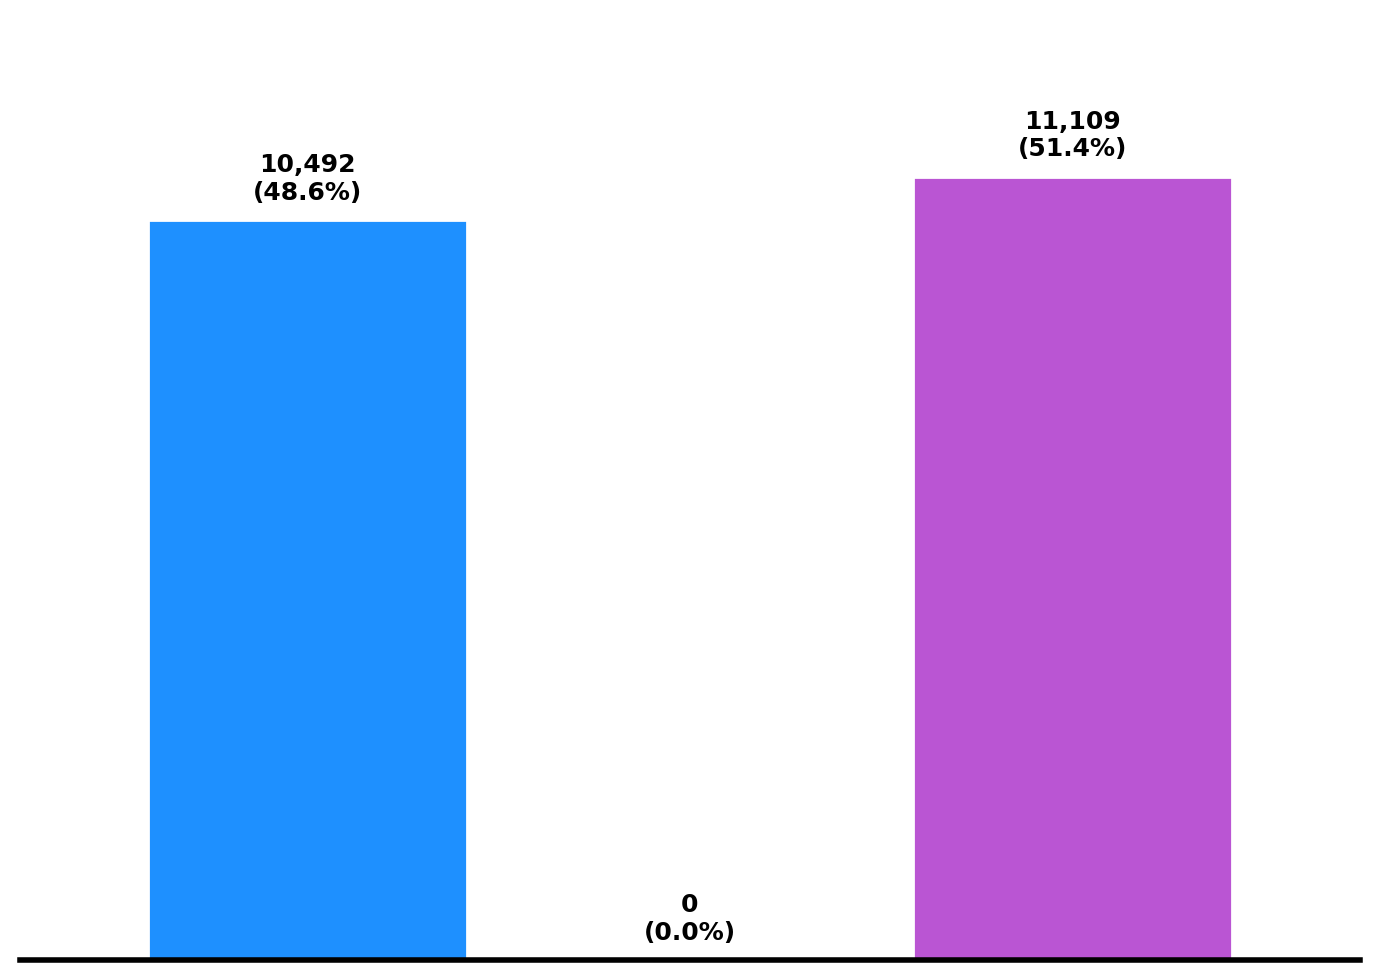

In [288]:
plot_c.plot_contact_barchart(counts, label1, label2, chrom="chr8")

Total non-zero contacts (union): 13,664
  Unique to PoreC - core: 5,499  (40.2%)
  Unique to core - core: 0  (0.0%)
  Shared: 8,165  (59.8%)


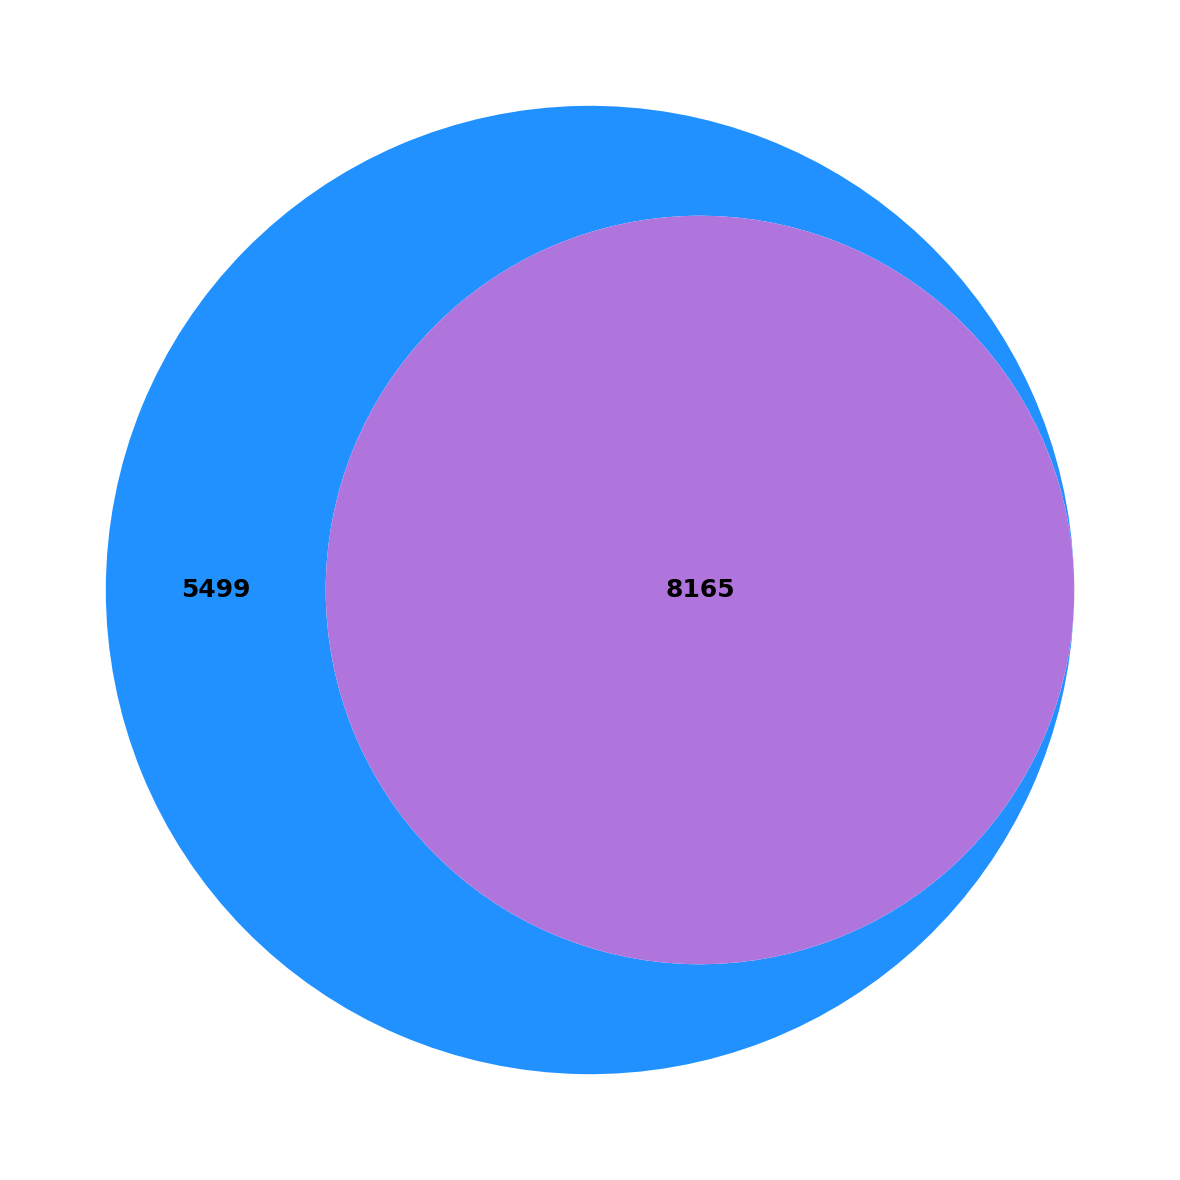

In [50]:
sets, counts, label1, label2 = plot_c.compute_contact_set_cardinality(raw_cell)

# Individual plots
plot_c.plot_contact_venn(sets, counts, label1, label2, chrom="chr8")

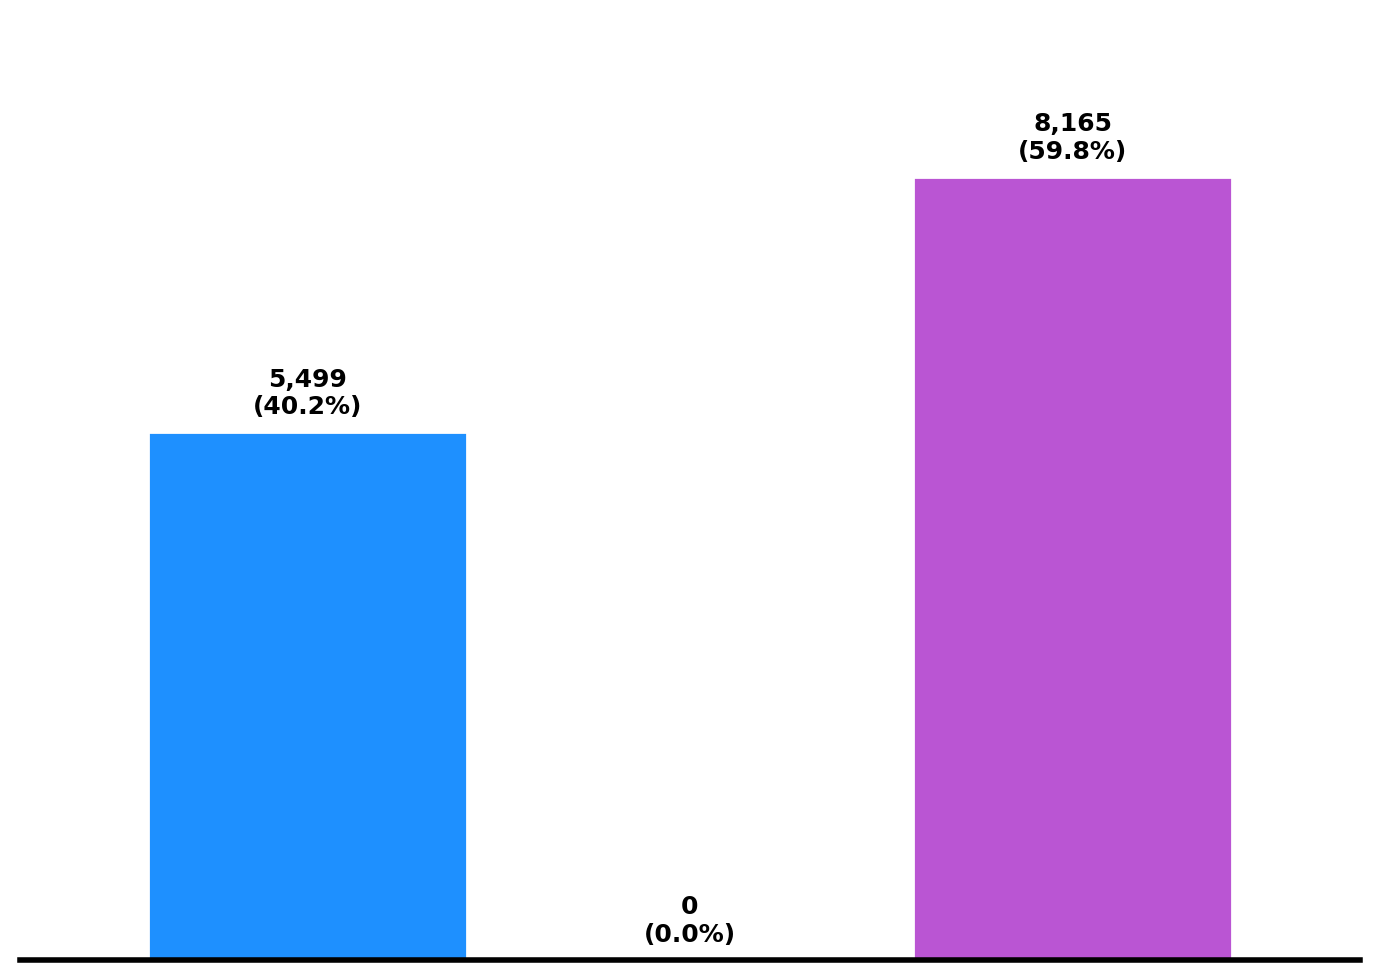

In [51]:
plot_c.plot_contact_barchart(counts, label1, label2, chrom="chr8")

In [318]:
raw_pop_cell = {}

raw_pop_cell['scPoreC - Chr8'] = raw_cell['scPoreC - Chr8']
raw_pop_cell['scHiC - Chr8'] = raw_pop['scHiC - Chr8']

Total non-zero contacts (union): 15,038
  Unique to scPoreC - Chr8: 5,642  (37.5%)
  Unique to scHiC - Chr8: 1,374  (9.1%)
  Shared: 8,022  (53.3%)


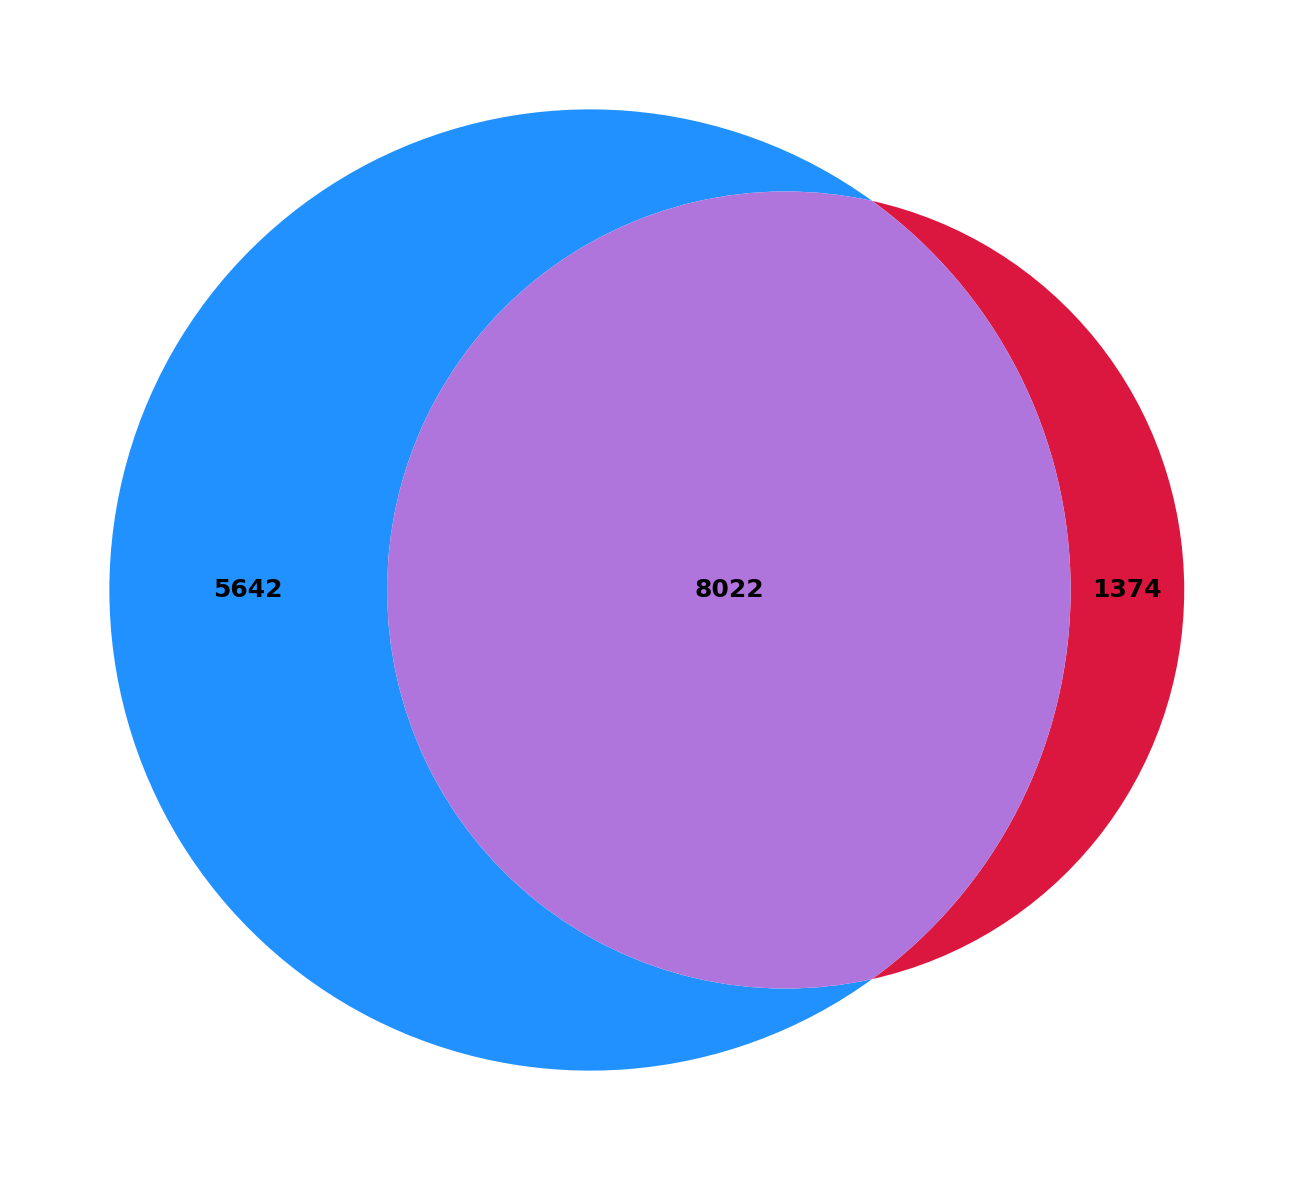

In [319]:
sets, counts, label1, label2 = plot_c.compute_contact_set_cardinality(raw_pop_cell)

# Individual plots
plot_c.plot_contact_venn(sets, counts, label1, label2, chrom="chr8")

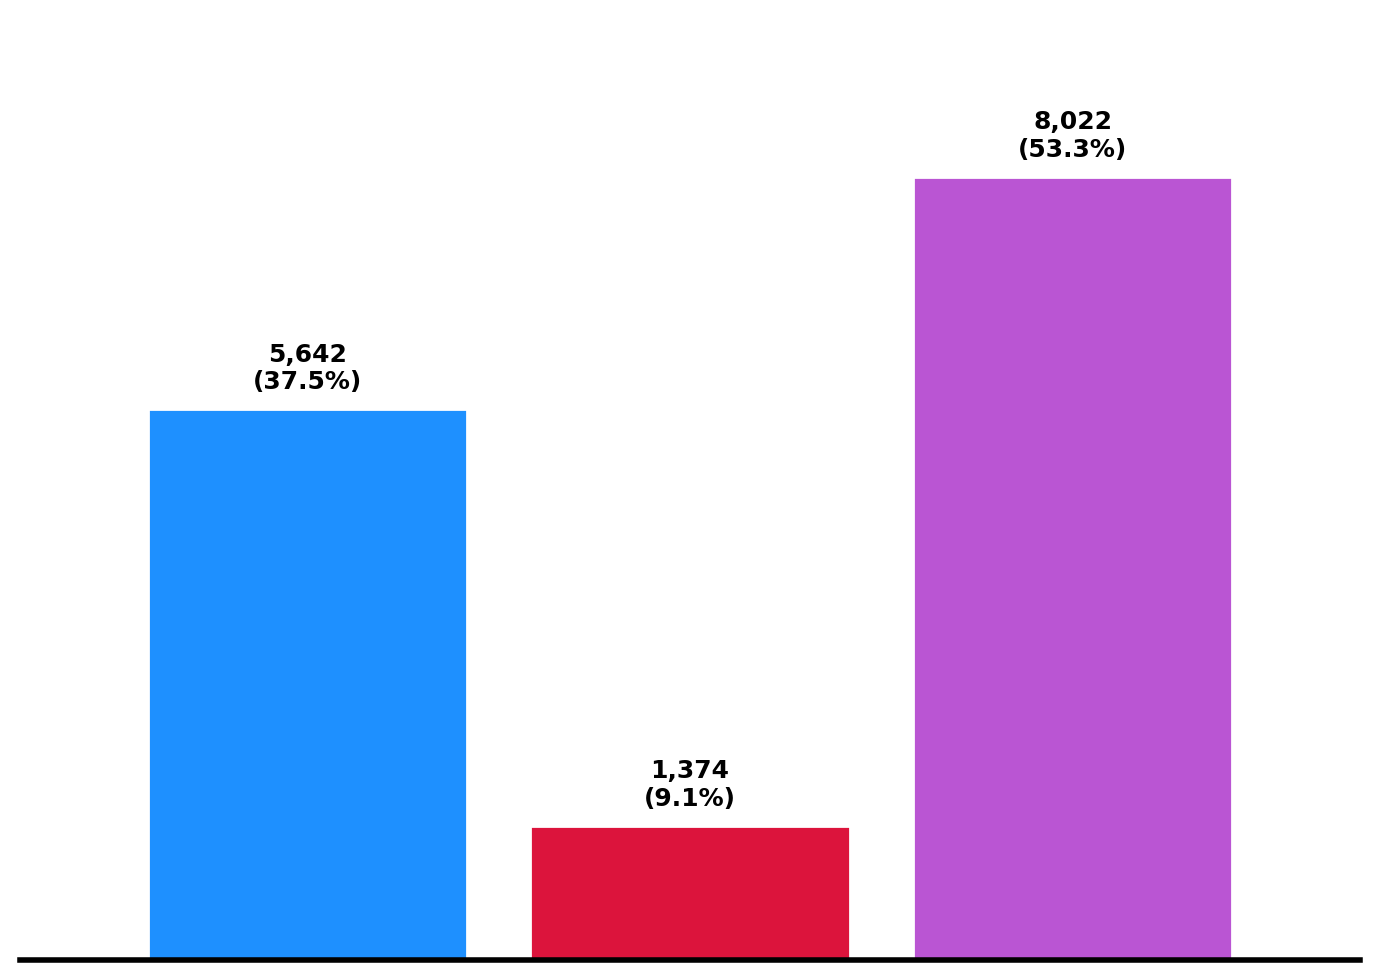

In [273]:
plot_c.plot_contact_barchart(counts, label1, label2, chrom="chr6")

In [37]:
core_matrix = pd.DataFrame(
    bdata.X.toarray() if sp.issparse(bdata.X) else bdata.X,
    index=bdata.obs_names
).reindex(cdata.obs_names).fillna(0).values

cdata.obsm["X_core"] = core_matrix

In [38]:
cdata.shape

(2579, 32545444)

In [52]:
mask_k = cdata.obs_names.str.startswith("chr2:")
cdata_filtered = cdata[mask_k, :].copy()

In [53]:
# Sort the obs index
sorted_index = sorted(cdata_filtered.obs_names, key=natural_sort_key)

# Reindex the AnnData object
cdata_sorted = cdata_filtered[sorted_index, :]

In [42]:
cdata_sorted.shape

(128, 32545444)

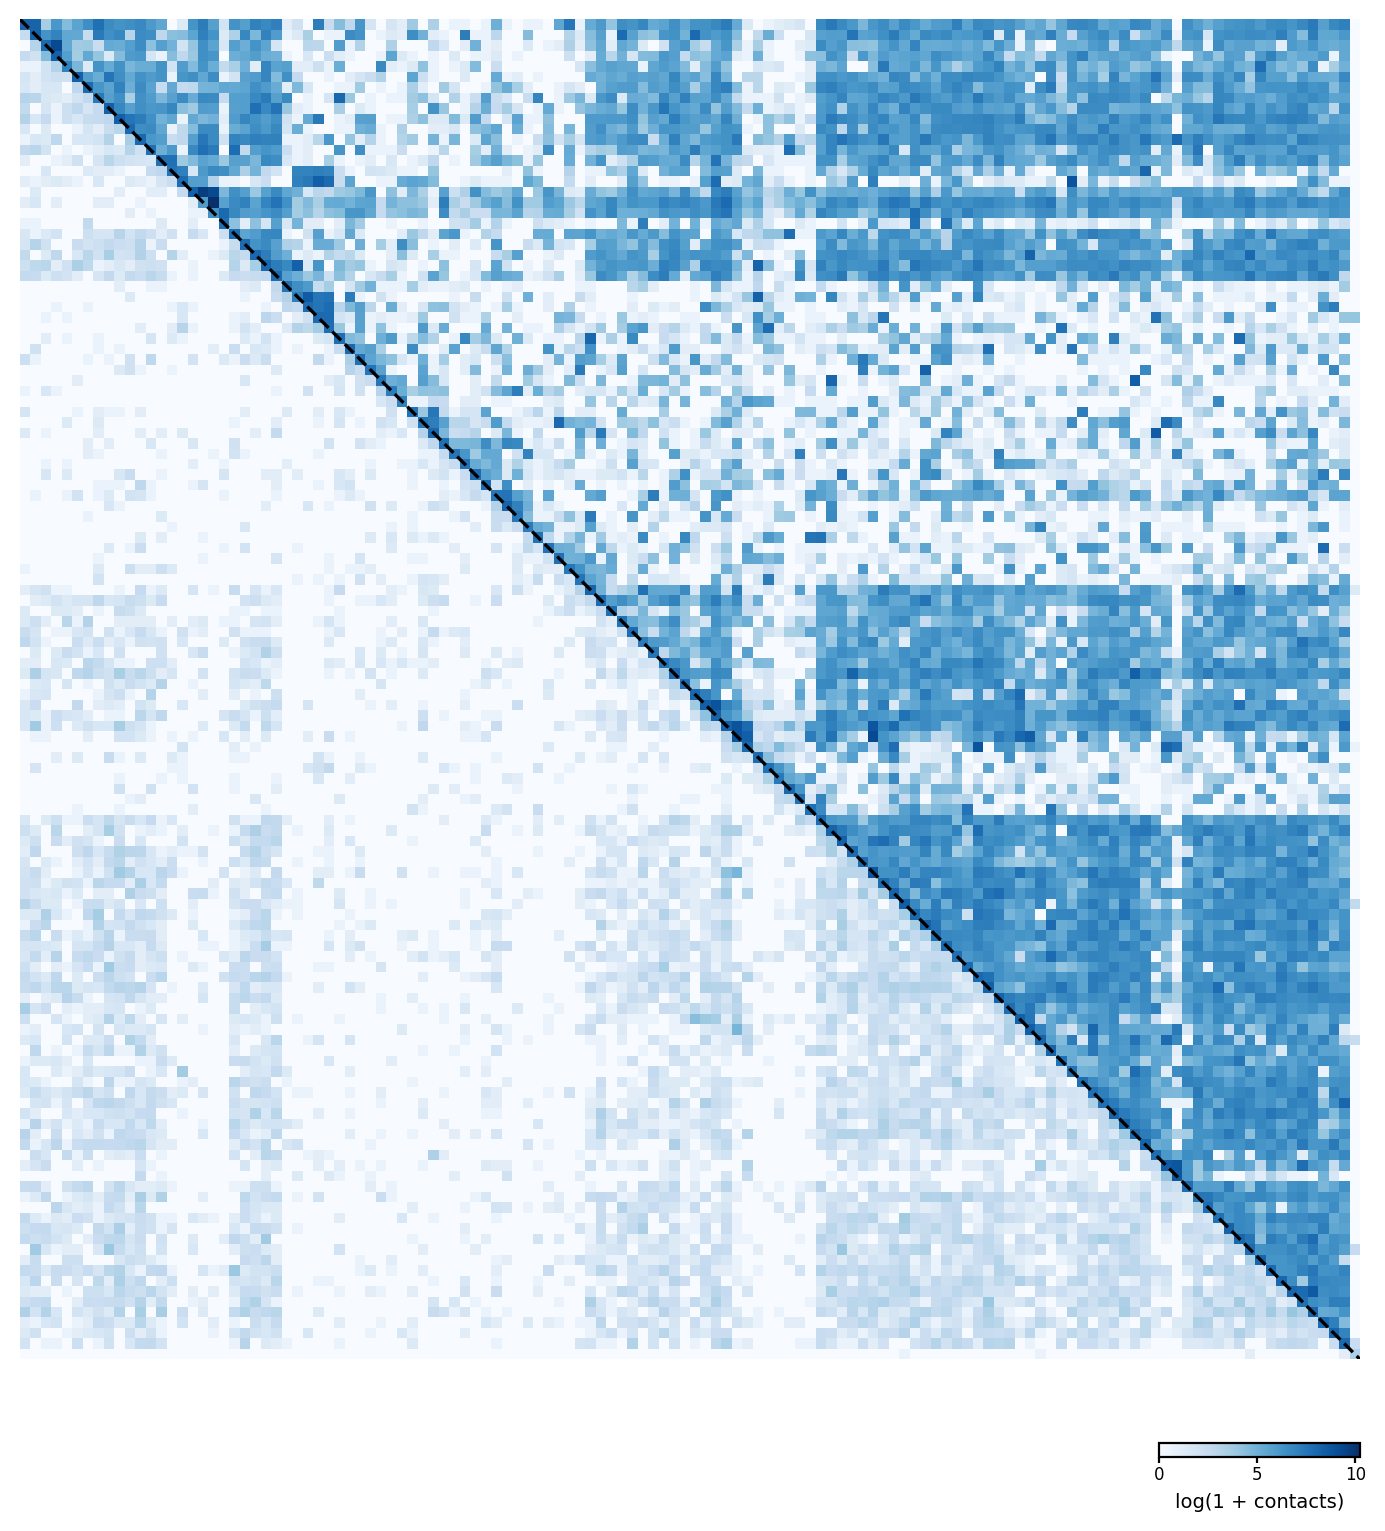

In [43]:
axes, raw_cell = plot_c.plot_panel_contact(
    sparse_matrix   = cdata_sorted.X,
    numpy_matrix    = master_cell,
    spath           = 'core_panel_contact_test.png',
    titles          = ('PoreC - core', 'core - core'),
    log_transform   = True,
    cmap            = 'Blues',
)

In [47]:
pore_c = raw_cell['PoreC - core']
hi_c = raw_cell['core - core']

In [48]:
js = jaccard_similarity(pore_c,hi_c)
print(js)

0.5975556206088993
